# Preparing data for TTS transformer

### Tokenizing text

In [ ]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torchaudio
import umap
from datasets import Audio, load_dataset
from phonemizer import phonemize
from phonemizer.separator import Separator
from plotly import express as px
from sklearn.cluster import KMeans
from transformers import AutoProcessor, EncodecModel

In [2]:
def extract_phonemes(text):
    phonemes = phonemize(
        text,
        language="ru",
        backend="espeak",
        separator=Separator(phone="#", word=" | "),
        preserve_punctuation=False,
        with_stress=True,
        strip=True,
    )
    return phonemes

In [3]:
pattern = re.compile(r"\\u[0-9a-fA-F]{4}\d?")
corpus = ""
with open("../data/corpus.txt", encoding="utf-8") as f:
    for line in f.readlines():
        line = re.sub(r"[\u2020-\u203f]\d?", "", line)
        corpus += line

In [4]:
vocab = set(
    ["<s_ph>", "</s_ph>", "</s_mel>", "<s_mel>", "<UNK_ph>", "<UNK_mel>", "<space>"]
)
for word in extract_phonemes(corpus).split(" | "):
    vocab.update([phoneme for phoneme in word.split("#") if phoneme.isalpha()])
vocab = list(vocab)

In [5]:
len(vocab)

69

In [6]:
phon_to_idx = {phoneme: i for i, phoneme in enumerate(vocab)}
idx_to_phon = {i: phoneme for i, phoneme in enumerate(vocab)}


def tokenize(text):
    phonemes = extract_phonemes(text)
    tokens = [phon_to_idx["<s_ph>"]]
    for word in phonemes.split(" | "):
        for phoneme in word.split("#"):
            if phoneme in phon_to_idx.keys():
                tokens.append(phon_to_idx[phoneme])
            else:
                tokens.append(phon_to_idx["<UNK_ph>"])
        tokens.append(phon_to_idx["<space>"])
    tokens.append(phon_to_idx["</s_ph>"])
    return tokens


def untokenize(tokens):
    phonemes = []
    for token in tokens:
        if token in idx_to_phon.keys():
            phonemes.append(idx_to_phon[token])
        else:
            phonemes.append("<UNK_ph>")
    return phonemes

In [7]:
text = "Это обычное тестовое предложение."
tokens = tokenize(text)
new_text = untokenize(tokens)
print(tokens)
print(new_text)

[26, 15, 68, 63, 55, 63, 27, 9, 17, 4, 63, 30, 54, 55, 62, 15, 38, 68, 63, 33, 63, 30, 54, 55, 16, 53, 59, 42, 47, 63, 58, 15, 49, 59, 30, 54, 55, 11]
['<s_ph>', 'ˈɛ', 't', 'ʌ', '<space>', 'ʌ', 'b', 'ˈy', 'tʃʲ', 'n', 'ʌ', 'j', 'ɪ', '<space>', 'tʲ', 'ˈɛ', 's', 't', 'ʌ', 'v', 'ʌ', 'j', 'ɪ', '<space>', 'p', 'rʲ', 'i', 'd', 'ɭ', 'ʌ', 'ʒ', 'ˈɛ', 'nʲ', 'i', 'j', 'ɪ', '<space>', '</s_ph>']


### Tokenizing audio

In [8]:
librispeech_dummy = load_dataset(
    "hf-internal-testing/librispeech_asr_dummy", "clean", split="validation"
)
model = EncodecModel.from_pretrained("facebook/encodec_24khz")
processor = AutoProcessor.from_pretrained("facebook/encodec_24khz")
librispeech_dummy = librispeech_dummy.cast_column(
    "audio", Audio(sampling_rate=processor.sampling_rate)
)
audio_sample = librispeech_dummy[-1]["audio"]["array"]
inputs = processor(
    raw_audio=audio_sample, sampling_rate=processor.sampling_rate, return_tensors="pt"
)
encoder_outputs = model.encode(inputs["input_values"], inputs["padding_mask"])
audio_values = model.decode(
    encoder_outputs.audio_codes, encoder_outputs.audio_scales, inputs["padding_mask"]
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [9]:
encoder_outputs.audio_codes.shape

torch.Size([1, 1, 2, 336])

In [64]:
second_codebook = model.quantizer.layers[1].codebook
embeddings = second_codebook.embed.numpy()
print("Embeddings shape:", embeddings.shape)
clusterized = KMeans(n_clusters=78).fit(embeddings)
labels = clusterized.labels_
centroids = clusterized.cluster_centers_
print("Centroids shape:", centroids.shape)
combined_embeddings = np.vstack([embeddings, centroids])
print("Resulting shape:", combined_embeddings.shape)
reducer = umap.UMAP(n_components=2)
embeddings_2d = reducer.fit_transform(combined_embeddings)
print("Reduced shape:", embeddings_2d.shape)

Embeddings shape: (1024, 128)
Centroids shape: (78, 128)
Resulting shape: (1102, 128)


/home/usr2/mambaforge/envs/ai_courses/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Reduced shape: (1102, 2)


In [83]:
df = pd.DataFrame.from_dict(
    [
        {
            "x": embeddings_2d[i, 0],
            "y": embeddings_2d[i, 1],
            "label": labels[i],
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(1024)
    ]
    + [
        {
            "x": embeddings_2d[i, 0],
            "y": embeddings_2d[i, 1],
            "label": i,
            "symbol": "star",
            "size_col": 10,
        }
        for i in range(78)
    ]
)

In [84]:
df.head()

,x,y,label,symbol,size_col
0,1.281769,7.051521,5,circle,4
1,-0.479801,6.723484,47,circle,4
2,-0.467186,4.255526,33,circle,4
3,1.879415,6.289966,58,circle,4
4,1.416401,4.261180,69,circle,4


In [85]:
df.tail()

,x,y,label,symbol,size_col
1097,3.614877,7.328878,73,star,10
1098,3.640711,7.095935,74,star,10
1099,0.017531,6.631328,75,star,10
1100,1.231240,6.908574,76,star,10
1101,4.112791,3.606398,77,star,10


In [91]:
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="label",
    size="size_col",
    symbol="symbol",
    width=1500,
    height=1000,
)
fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)
fig.update_layout(
    title="<b>2D-projection of 2nd codebook embeddings</b>",
)
fig.show()

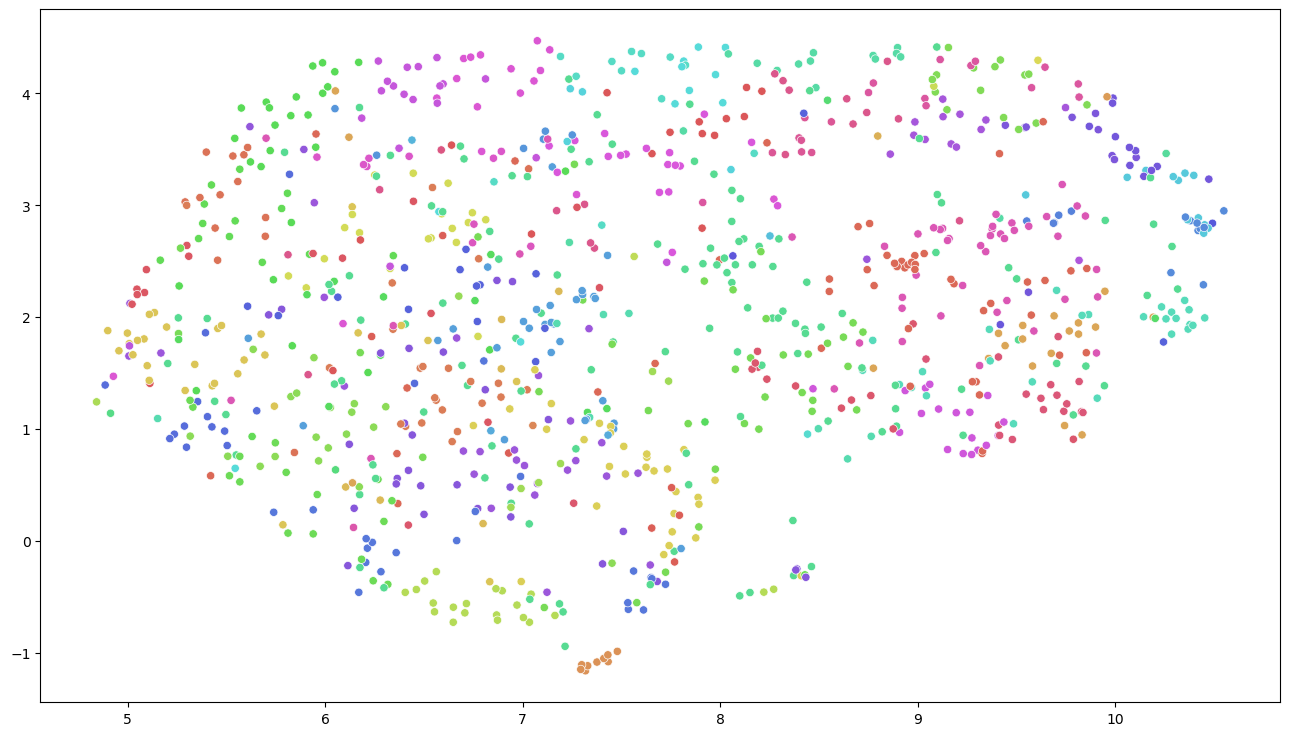

In [ ]:
plt.figure(figsize=(16, 9))
palette = sns.color_palette("hls", 78)
sns.scatterplot(
    x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels, palette=palette
)
plt.legend([], [], frameon=False)